## Diabetic Dataset - Overview:

768 Samples of Pima India woman (21+ years old) with 8 features and 1 target variable (Outcome)

### Feature Significance:

1. Pregnancies – More pregnancies may increase diabetes risk.
2. Glucose – High levels indicate diabetes risk.
3. BloodPressure – Hypertension is linked to diabetes.
4. SkinThickness – Indicates body fat, related to insulin resistance.
5. Insulin – Helps assess glucose regulation.
6. BMI – Higher BMI increases diabetes risk.
7. DiabetesPedigreeFunction – Genetic predisposition to diabetes.
8. Age – Older individuals have a higher risk.

## ii. Analyze the data following appropriate descriptive statistical methods, hypothesis testing, correlation etc. in order to answer the posed research question.

(use appropriate visualization tool, programming)

## 1. Libraries

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

from scipy.stats import ttest_ind

from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings(action='ignore')

## 2. Load Data

In [ ]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Exploratory Data Analysis

### 3.a. Explore Data Characteristics

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Key Insights**


> 1. No missing values (all features have 768 entries), but 0 values in Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin and	BMI suggest missing data.
> 2. Glucose (mean: 121 mg/dL, max: 199 mg/dL) shows a wide range, with possible outliers.
> 3. BMI (mean: 32), Age (mean: 33), and Blood Pressure (mean: 69 mmHg) align with diabetes risk factors.
> 4. High variance in Insulin (std: 115, max: 846) suggests extreme values.
> 5. 25% of SkinThickness & Insulin values are 0, indicating potential data quality issues.


### 3.b. Checking and removing missing data

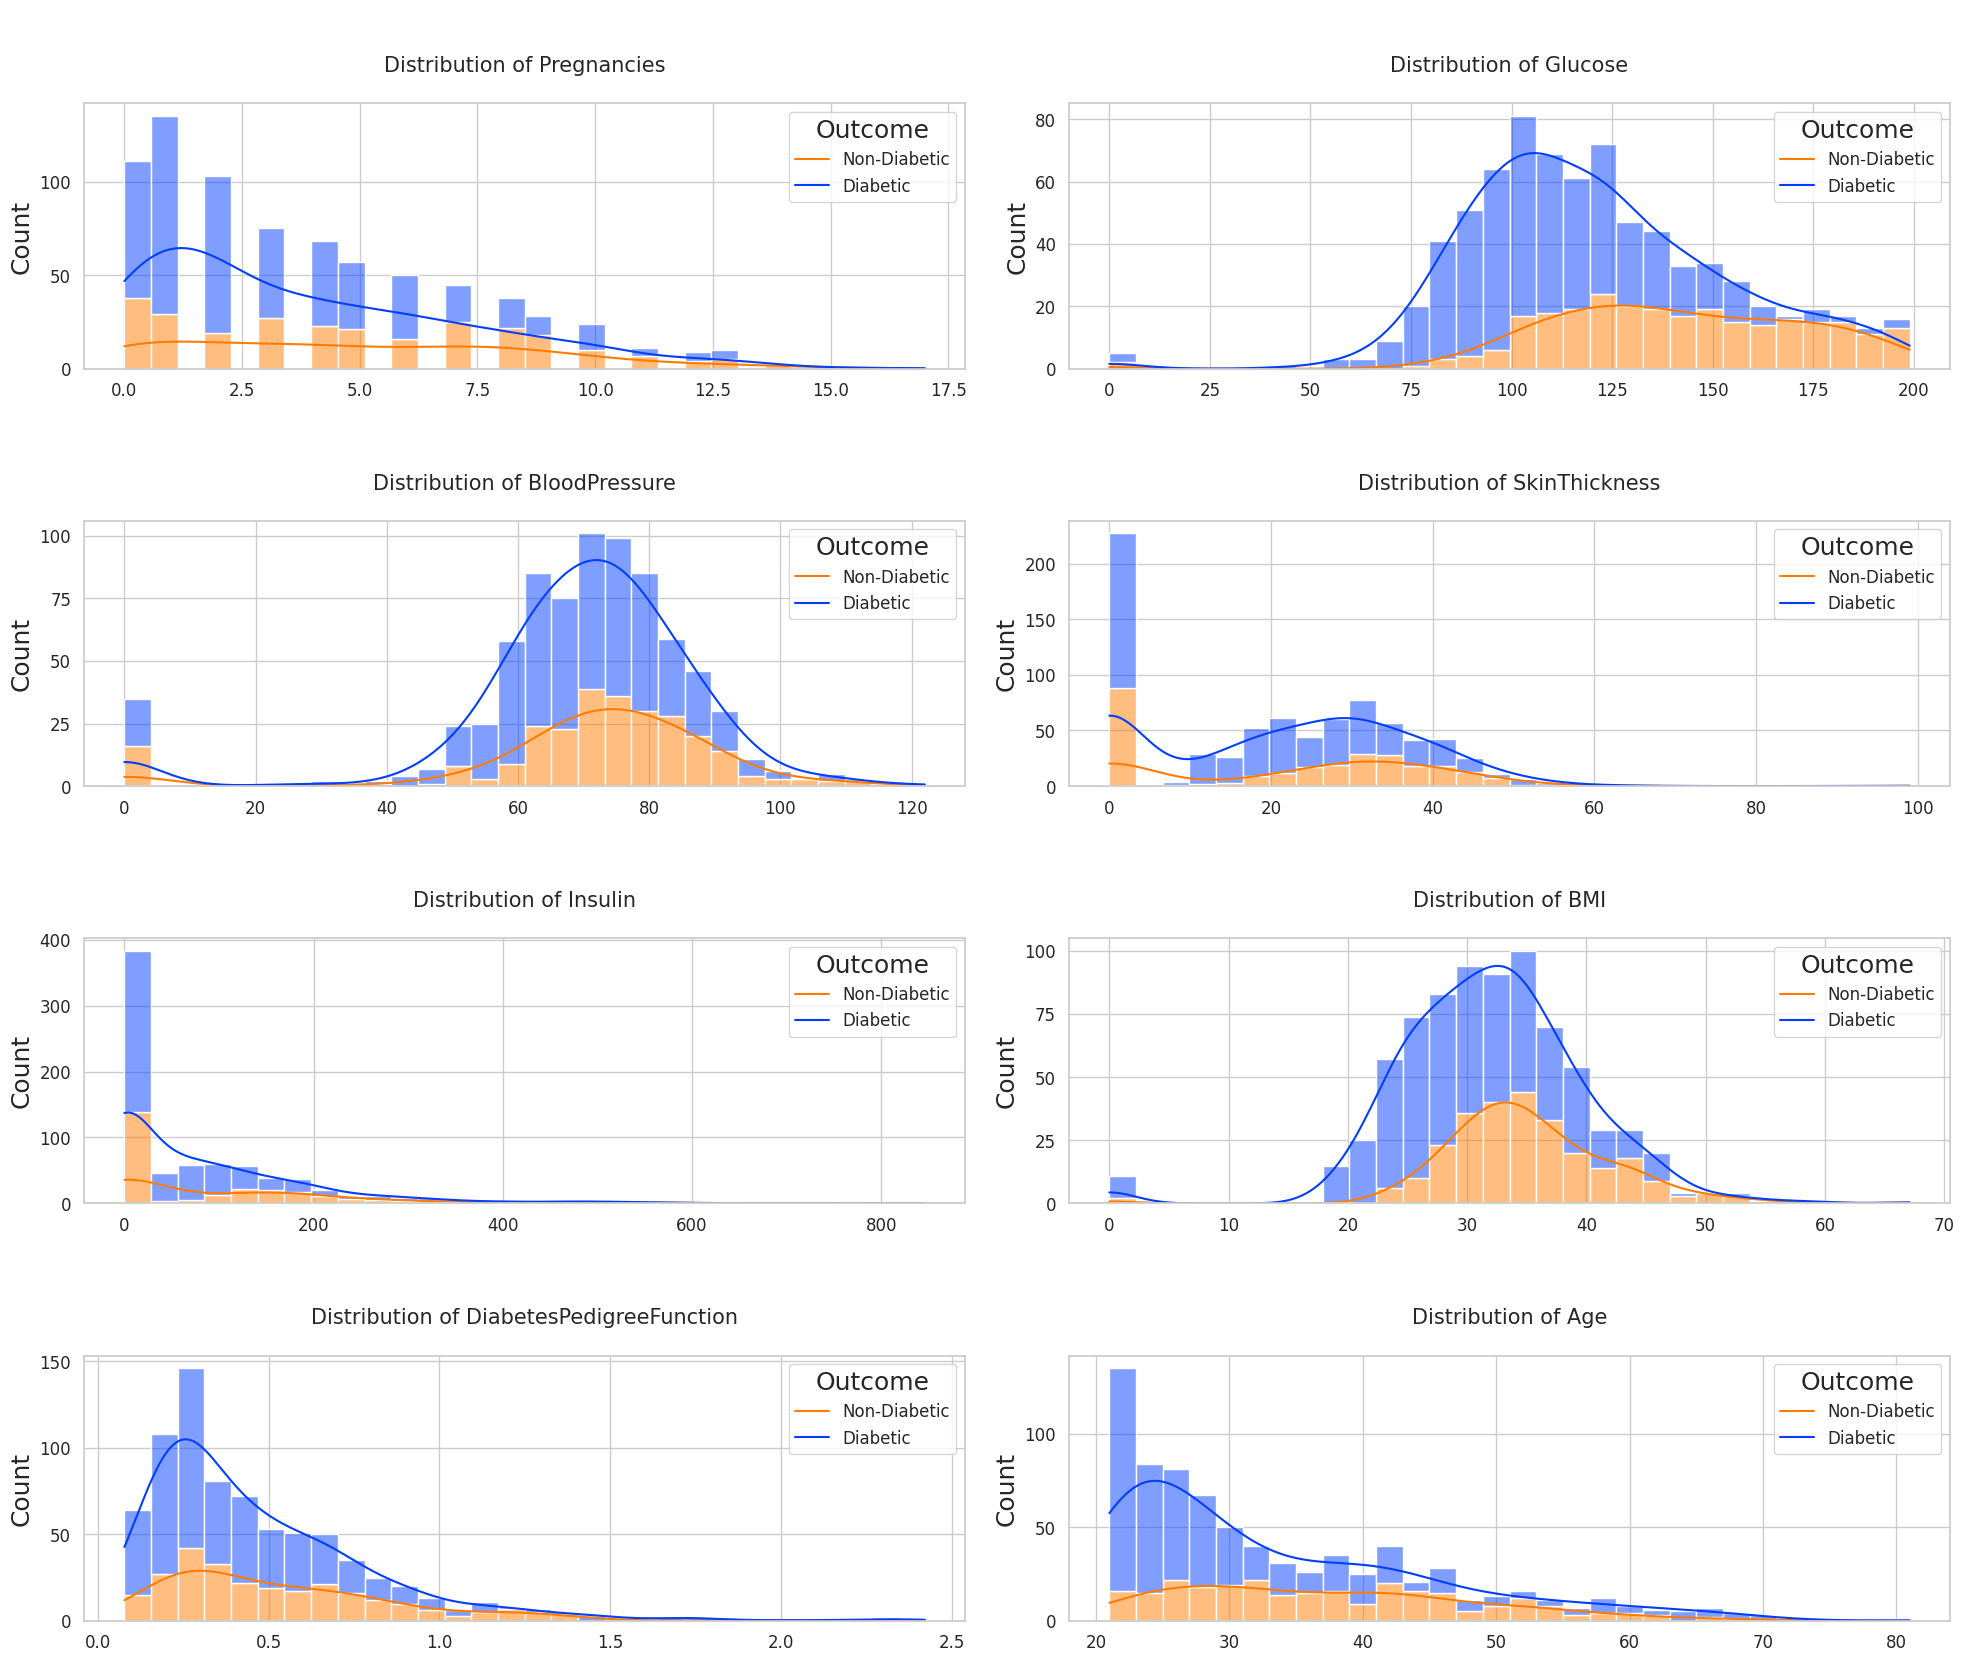

In [5]:
# Set visualization parameters
sns.set(font_scale=1.5, style="whitegrid", palette="bright")
plt.figure(figsize=(20, 25))

# Define features (excluding Outcome)
feature_names = df.columns[:-1]

# Define custom legend labels
legend_labels = ["Non-Diabetic", "Diabetic"]

# Plot histograms for each feature grouped by Outcome
for i, name in enumerate(feature_names, 1):
    plt.subplot(6, 2, i)
    sns.histplot(data=df, x=name, hue="Outcome", kde=True, bins=30, multiple="stack", palette="bright")
    plt.legend(legend_labels, title="Outcome", fontsize=12)
    plt.xlabel("")  # Remove x-axis label (feature name)
    plt.title(f"\n\nDistribution of {name}\n", fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

From the above plots, it would be good to change the zero value of each feature to another value. First, let's calculate the proportion of zero values in each feature.

In [6]:
# Define features that may contain zero values
zero_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_count = len(df)  # Total number of records

# Print zero value statistics in a cleaner format
print("Feature-wise Zero Value Analysis:\n" + "-"*40)
for feature in zero_features:
    zero_count = (df[feature] == 0).sum()
    zero_percent = (zero_count / total_count) * 100
    print(f"{feature}: {zero_count} cases ({zero_percent:.2f}%)")
print("-"*40)

Feature-wise Zero Value Analysis:
----------------------------------------
Pregnancies: 111 cases (14.45%)
Glucose: 5 cases (0.65%)
BloodPressure: 35 cases (4.56%)
SkinThickness: 227 cases (29.56%)
Insulin: 374 cases (48.70%)
BMI: 11 cases (1.43%)
----------------------------------------


**Key Insights**

> 1. Insulin (48.70%) and Skin Thickness (29.56%) have the highest proportion of zero values, suggesting missing or unreliable data.
> 2. Glucose and BMI have relatively few zero values, indicating minimal data quality concerns.
> 3. Pregnancies (14.45%) might be valid as some women may not have had any pregnancies.

Lets replace the corresponding value with the mean value.


In [7]:
diabetes_mean = df[zero_features].mean()
df[zero_features]=df[zero_features].replace(0, diabetes_mean)

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.400782,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,2.984162,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.845052,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Here we can see that the zero value is removed.

### 3.c. Scaling

Since some features exhibit a one-sided distribution, we replaced zero values with the mean and applied nonlinear scaling. To achieve a distribution closest to normal, we chose QuantileTransformer.

In [9]:
# Define features to transform (excluding 'Outcome')
features_to_transform = df.columns[:-1]

# Initialize and apply the QuantileTransformer
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
df[features_to_transform] = quantile_transformer.fit_transform(df[features_to_transform])

# Display the first few rows of the transformed data
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.667327,0.879002,0.042498,0.848159,-0.305344,0.230799,0.677570,1.225627,1
1,-5.199338,-1.333008,-0.553118,0.371103,-0.305344,-0.795477,-0.060497,0.147598,0
2,1.097346,1.716615,-0.727771,-0.498698,-0.305344,-1.421574,0.779878,0.215722,1
3,-5.199338,-1.152728,-0.553118,0.014707,0.420590,-0.570338,-1.246676,-5.199338,0
4,-0.050677,0.587729,-2.561229,0.848159,0.971779,1.453722,2.793437,0.269580,1


### 3.d. Distribution of Outcome (Target variable)

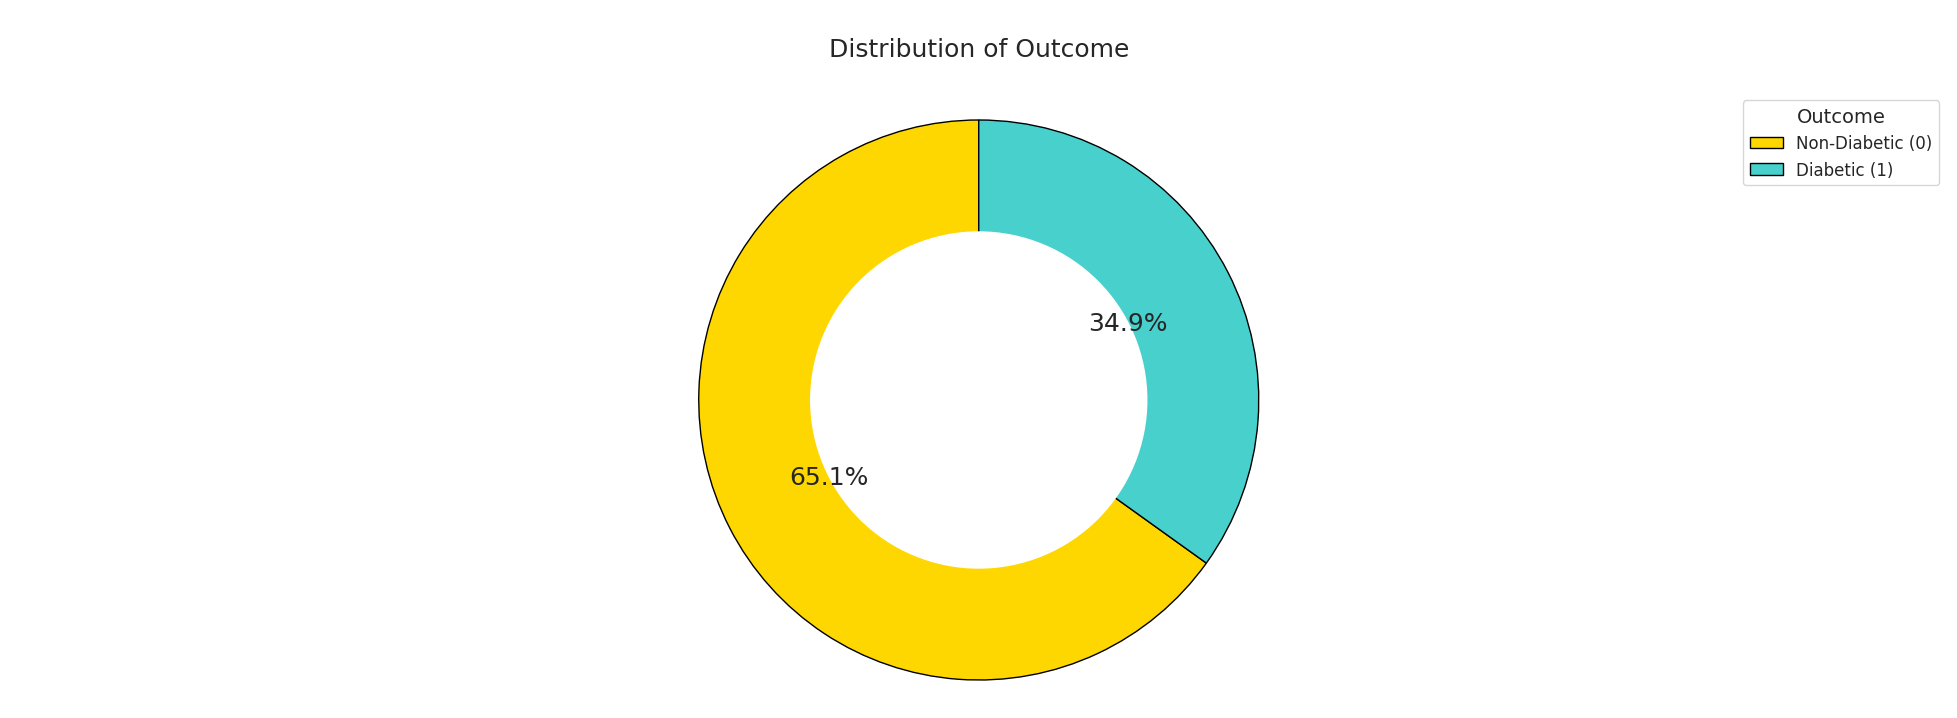

In [10]:
# Define the outcome counts
outcome_counts = df['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ['gold', 'mediumturquoise']

# Create the pie chart with a donut hole
plt.figure(figsize=(25, 8))  # More balanced figure size
plt.pie(outcome_counts, labels=None, autopct='%1.1f%%', colors=colors, 
        startangle=90, wedgeprops={'edgecolor': 'black'})

# Create the donut hole
plt.gca().add_artist(plt.Circle((0, 0), 0.6, color='white'))
plt.legend(labels, title="Outcome", loc="upper right", title_fontsize=14, fontsize=12)
plt.axis('equal')  # Ensures the pie chart is circular and centered
plt.title('\nDistribution of Outcome\n')
plt.show()


This donut chart represents the distribution of diabetes outcomes in the dataset:

1. Majority Class (Non-Diabetic, 65.1%):    
    * About 65.1% of the individuals in the dataset do not have diabetes (Outcome = 0).
    * This indicates that the dataset is imbalanced, with more non-diabetic cases.
<br><br>
2. Minority Class (Diabetic, 34.9%)
    * Around 34.9% of the individuals in the dataset have diabetes (Outcome = 1).

### 3.e. Hypothesis Testing for Diabetes Outcome

In [11]:
# Exclude the Outcome column
features = df.columns[:-1]  

# Perform t-tests for each feature
results = []
for feature in features:
    group_0 = df[df['Outcome'] == 0][feature]  # Non-Diabetic
    group_1 = df[df['Outcome'] == 1][feature]  # Diabetic
    t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)
    results.append([feature, t_stat, p_value])

# Convert results to DataFrame
t_test_results = pd.DataFrame(results, columns=["Feature", "T-Statistic", "P-Value"])

# Add significance interpretation
t_test_results["Significance"] = t_test_results["P-Value"].apply(lambda p: "Significant" if p < 0.05 else "Not Significant")

# Display results
t_test_results

,Feature,T-Statistic,P-Value,Significance
0,Pregnancies,-5.673242,2.147632e-08,Significant
1,Glucose,-14.942873,1.210890e-42,Significant
2,BloodPressure,-4.670671,3.744616e-06,Significant
3,SkinThickness,-5.190258,2.944601e-07,Significant
4,Insulin,-6.134272,1.655486e-09,Significant
5,BMI,-9.533914,3.347320e-20,Significant
6,DiabetesPedigreeFunction,-5.075435,5.344433e-07,Significant
7,Age,-8.547495,6.812624e-17,Significant


**Key Objective:**

All features show significant differences between diabetic and non-diabetic individuals (p-value < 0.05). This means these factors strongly influence diabetes risk.

>1. Glucose (T = -14.94, p ≈ 0) → Strongest impact on diabetes
>2. BMI, Age, Insulin, and Pregnancies also show strong statistical differences
>3. Blood Pressure & Skin Thickness are significant but have a relatively lower T-statistic

### 3.f. Boxplot visualization

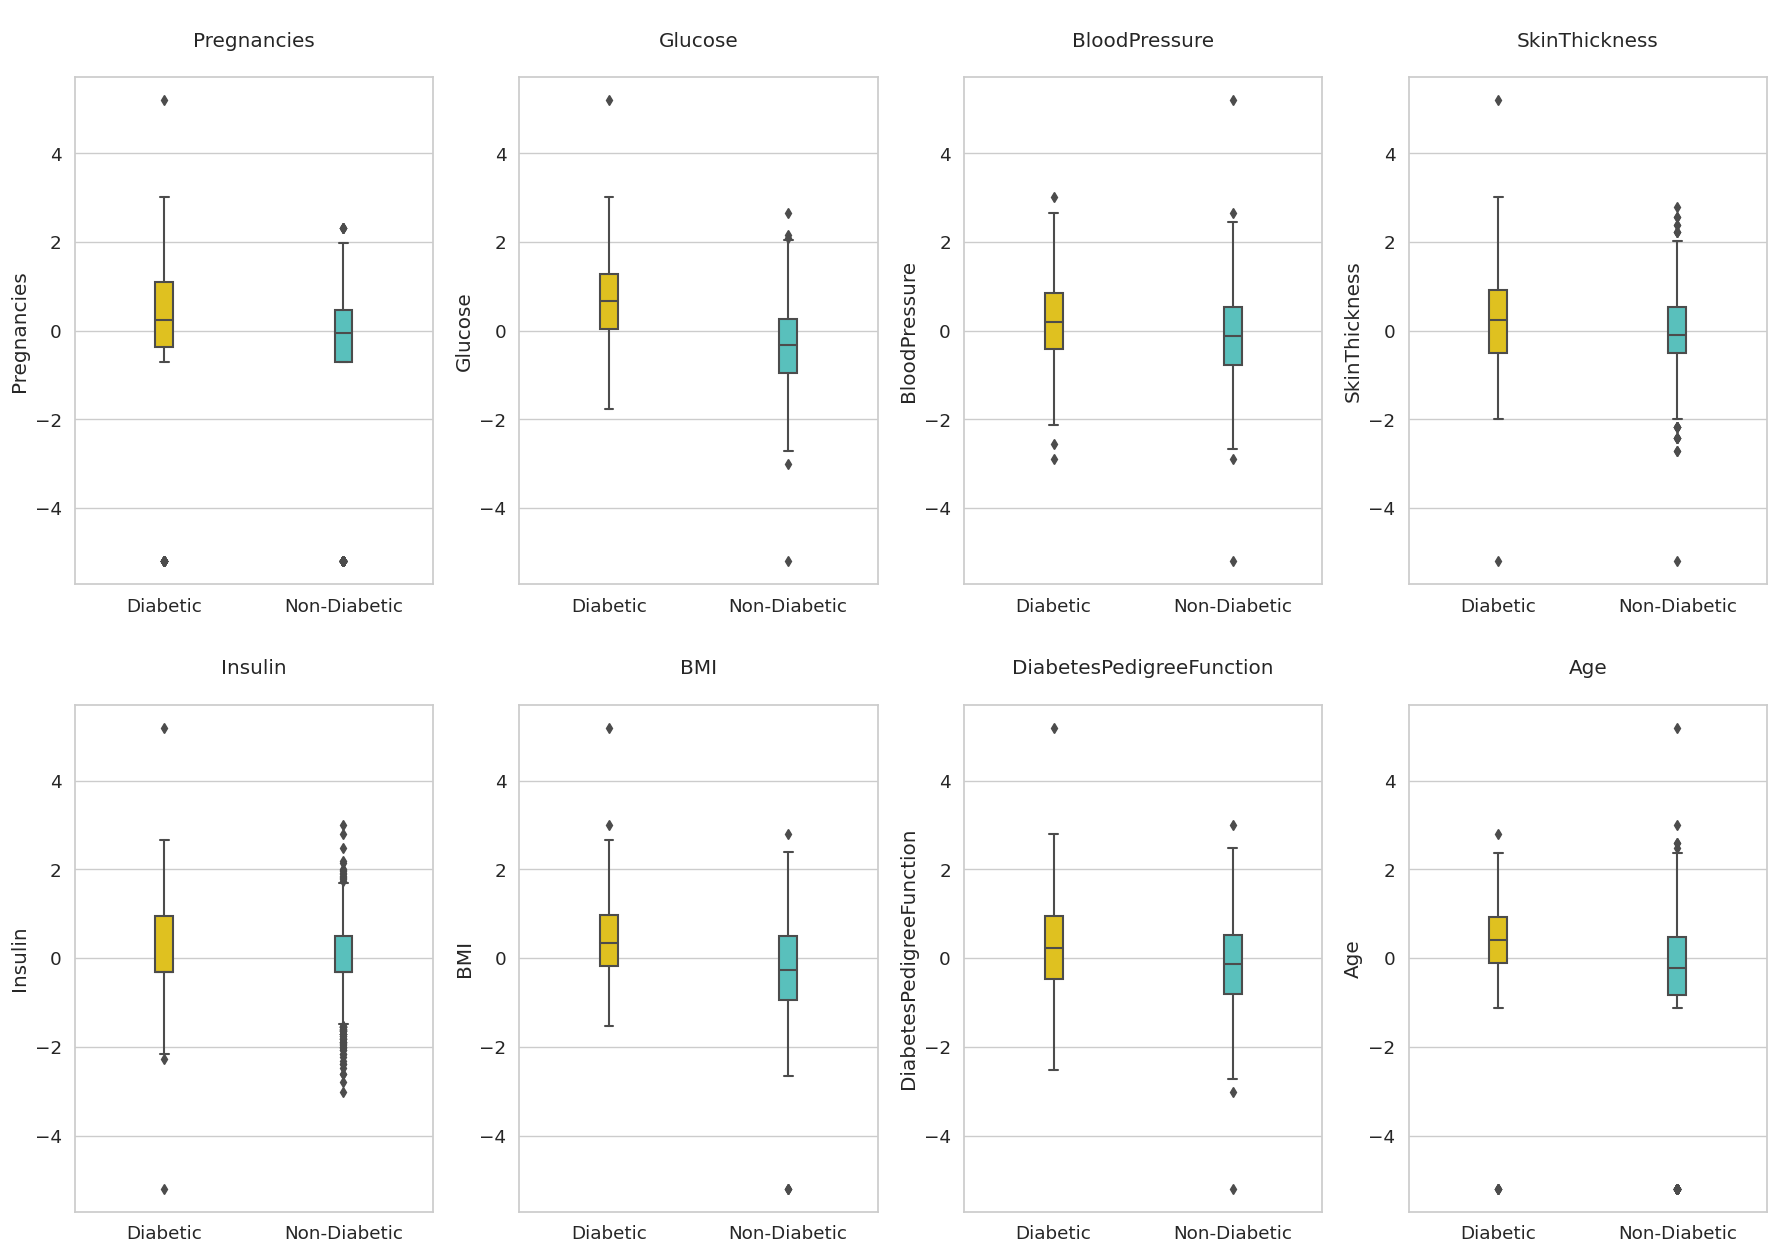

In [12]:
# Set style
sns.set(font_scale=1.2, style="whitegrid", palette="bright")

# Define features explicitly excluding Outcome
features = [col for col in df.columns if col not in ['Outcome', 'Outcome_Label']]

# Rename outcome values for better labeling
df["Outcome_Label"] = df["Outcome"].map({0: "Non-Diabetic", 1: "Diabetic"})

# Adjust grid size (set rows to fit all features)
num_features = len(features)
rows = (num_features // 2) + (num_features % 2)  # Ensure all features fit

plt.figure(figsize=(18, 25))  # Increase figure size

for i, feature in enumerate(features, 1):
    plt.subplot(rows, 4, i)  # Adjust grid size dynamically
    sns.boxplot(data=df, x="Outcome_Label", y=feature, palette=["gold", "mediumturquoise"], width=0.1)
    plt.title(f"\n{feature}\n")
    plt.xlabel("")  # Remove default axis label
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

**Key insights:**

> 1. Glucose: Higher median and interquartile range in diabetics, indicating a strong link to diabetes.
> 2. BMI & Age: Diabetics tend to have higher values, suggesting an association with diabetes risk.
> 3. Insulin & SkinThickness: More outliers in non-diabetics, implying higher variability in measurements.
> 4. Blood Pressure & DiabetesPedigreeFunction: Slightly higher medians in diabetics but less distinct separation.
> 5. Pregnancies: Higher in diabetics, reinforcing that more pregnancies may increase diabetes risk.

Overall, glucose, BMI, and age show the most significant differences between the groups.

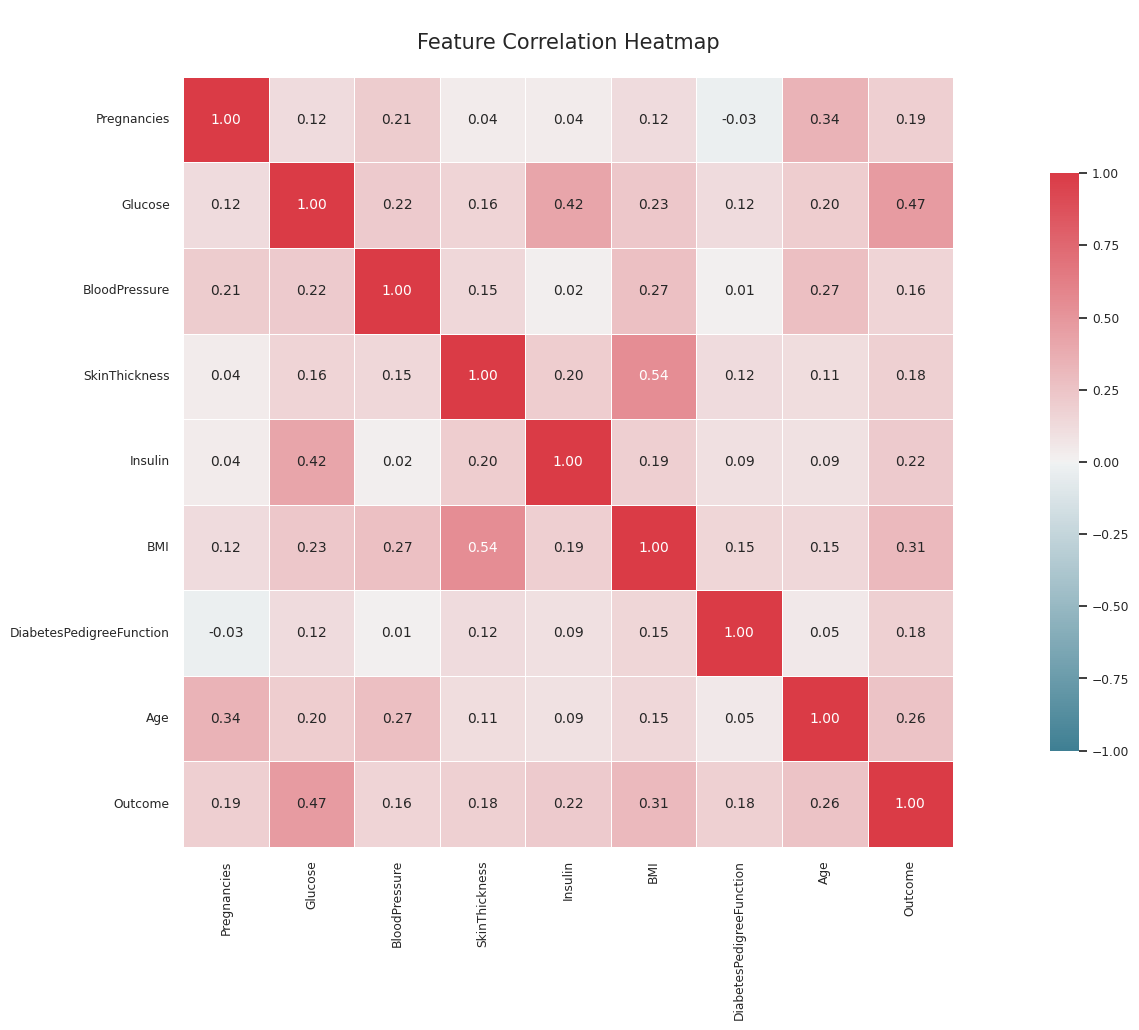

In [13]:
# Set Seaborn style
sns.set(font_scale=0.8, style="whitegrid", palette=sns.color_palette())

# Compute correlation matrix (excluding Outcome_Label if present)
df_corr = df.drop(columns=["Outcome_Label"], errors="ignore").corr()

# Set up the figure
plt.figure(figsize=(25, 10))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Create heatmap with improved aesthetics
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap=cmap,  
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.75}, 
            annot_kws={"size": 10}, center=0, vmin=-1, vmax=1)

# Improve title aesthetics
plt.title("\nFeature Correlation Heatmap", fontsize=15, pad=20)

# Show the plot
plt.show()

**Key Insights**

> 1. Glucose seems to be the most relevant feature for predicting diabetes (highest correlation with Outcome).
> 2. Other features like BMI, Age, and Insulin may contribute but are weaker predictors.
> 3. Blood Pressure & SkinThickness show weaker correlations with diabetes, so they might not be strong indicators on their own.

## 4. Model

### 4.1. Train test split

In [14]:
# Load the dataset (assuming df is already defined)
X = df.drop(columns=["Outcome", "Outcome_Label"])  # Features
y = df["Outcome"]  # Target variable

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 4.2. Deal with Imbalanced Data

In [15]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### 4.3. Random Forest with hyperparameter tuning

In [16]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 500, 100],  # Number of trees
    'max_depth': [None, 10, 20],  # Maximum depth of trees
    'min_samples_split': [2, 5],  # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4]  # Minimum samples per leaf
}

# Perform hyperparameter tuning
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

# Get best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Train Random Forest with best parameters
best_rf = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42)
best_rf.fit(X_resampled, y_resampled)

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

### 4.5. Feature Importance

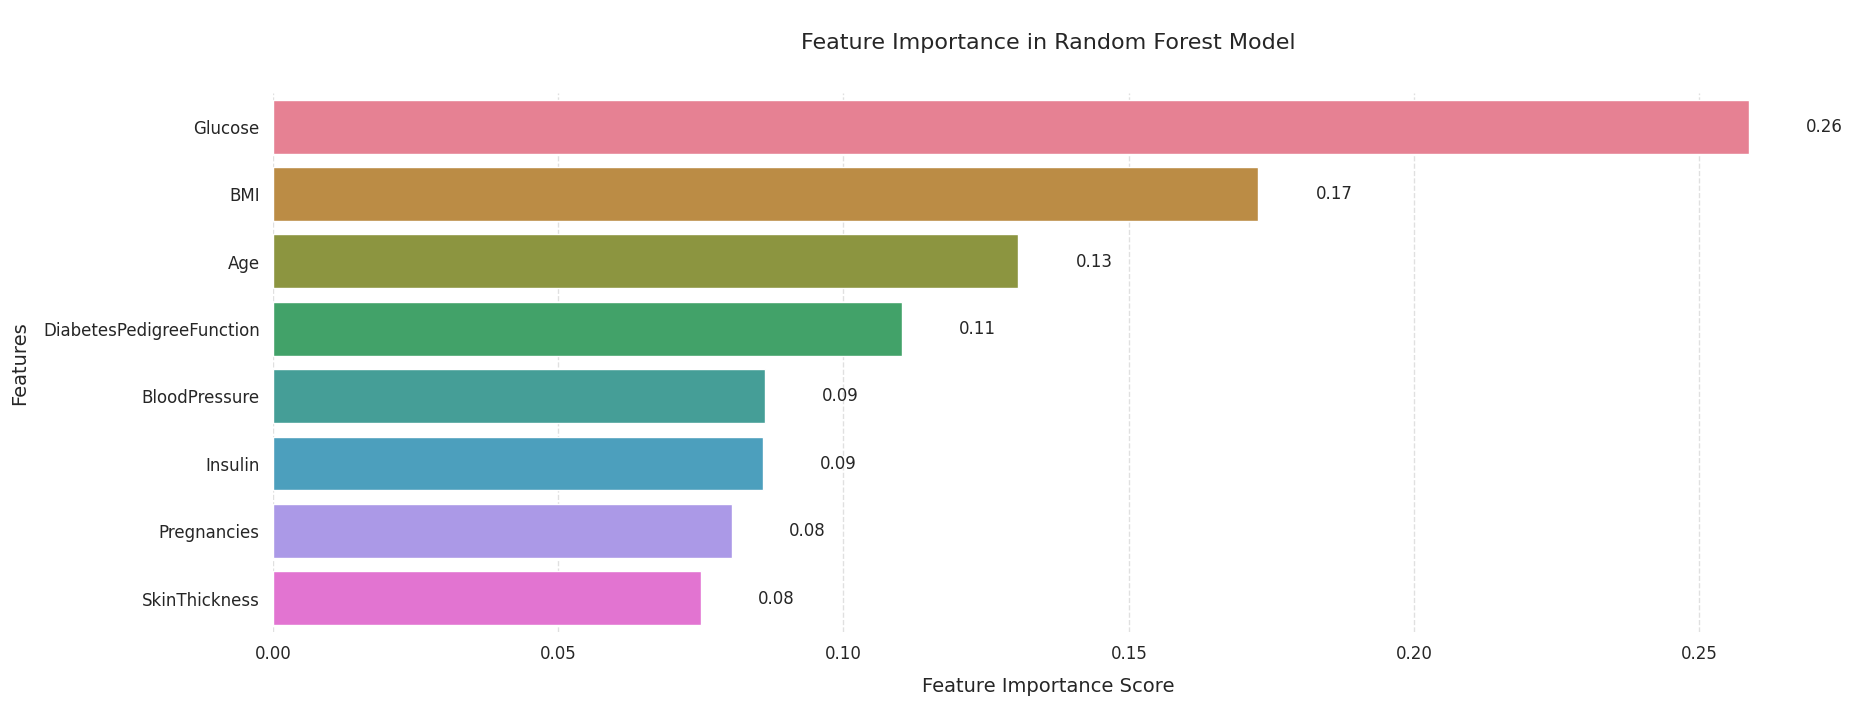

In [17]:
# Get feature importance
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(20, 7))
sns.barplot(x=feature_importances, y=feature_importances.index, palette=sns.color_palette("husl", 8))

# Add values on bars for better readability
for index, value in enumerate(feature_importances):
    plt.text(value + 0.01, index, f"{value:.2f}", va="center", fontsize=12)

# Labels and title with styling
plt.xlabel("Feature Importance Score", fontsize=14, labelpad=10)
plt.ylabel("Features", fontsize=14, labelpad=10)
plt.title("\nFeature Importance in Random Forest Model\n", fontsize=16, pad=15)

# Improve layout aesthetics
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine(left=True, bottom=True)

# Show the plot
plt.show()

In [18]:
# Select top 5 important features
selected_features = feature_importances.index[:5]
print(f"Selected Features: {list(selected_features)}")

# Use only selected features for training
X_train_selected = X_resampled[selected_features]
X_test_selected = X_test[selected_features]

# Train final Random Forest model
final_rf = RandomForestClassifier(**best_params, random_state=42)
final_rf.fit(X_train_selected, y_resampled)

Selected Features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'BloodPressure']


RandomForestClassifier(n_estimators=500, random_state=42)

### 4.6. Evalution

Random Forest Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.65      0.72      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.77      0.77       154



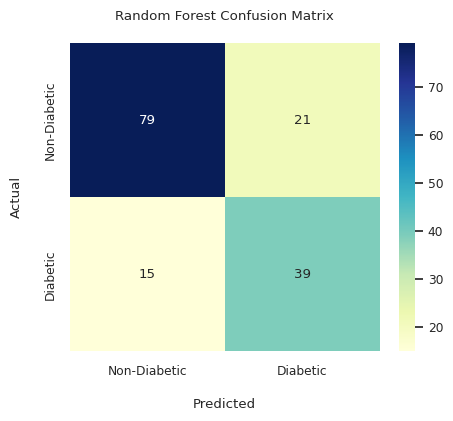

In [19]:
# Make predictions
y_pred = final_rf.predict(X_test_selected)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Random Forest Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(class_report)

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["Non-Diabetic", "Diabetic"], yticklabels=["Non-Diabetic", "Diabetic"])
plt.xlabel("\nPredicted")
plt.ylabel("Actual\n")
plt.title("Random Forest Confusion Matrix\n")
plt.show()

**Key Takeaways**:

> 1. ***Overall Accuracy***: 77% with Random Forest.
> 2. ***Non-Diabetic (Class 0)***:<br>
    a. ***Precision (84%)***: When predicting "Non-Diabetic," 84% of those predictions were correct.<br>
    b. ***Recall (79%)***: Out of all actual "Non-Diabetic" cases, 79% were correctly identified.<br>
    c. ***F1-score (81%)***: Good balance between precision and recall.
> 3. ***Diabetic (Class 1)***:<br>
    a. ***Precision (65%)***: 65% of "Diabetic" predictions were correct.<br>
    b. ***Recall (72%)***: 72% of actual diabetics were correctly identified.<br>
    c. ***F1-score (68%)***: Better than before but still slightly lower than Class 0.